In [1]:
# Étape 1 : Chargement des bibliothèques et des données
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

ModuleNotFoundError: No module named 'pandas'

In [2]:
# Chargement du dataset Iris (inclus dans scikit-learn)
from sklearn.datasets import load_iris
iris = load_iris()
df = pd.DataFrame(data=np.c_[iris['data'], iris['target']],
                  columns=iris['feature_names'] + ['target'])
print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0     0.0  
1     0.0  
2     0.0  
3     0.0  
4     0.0  


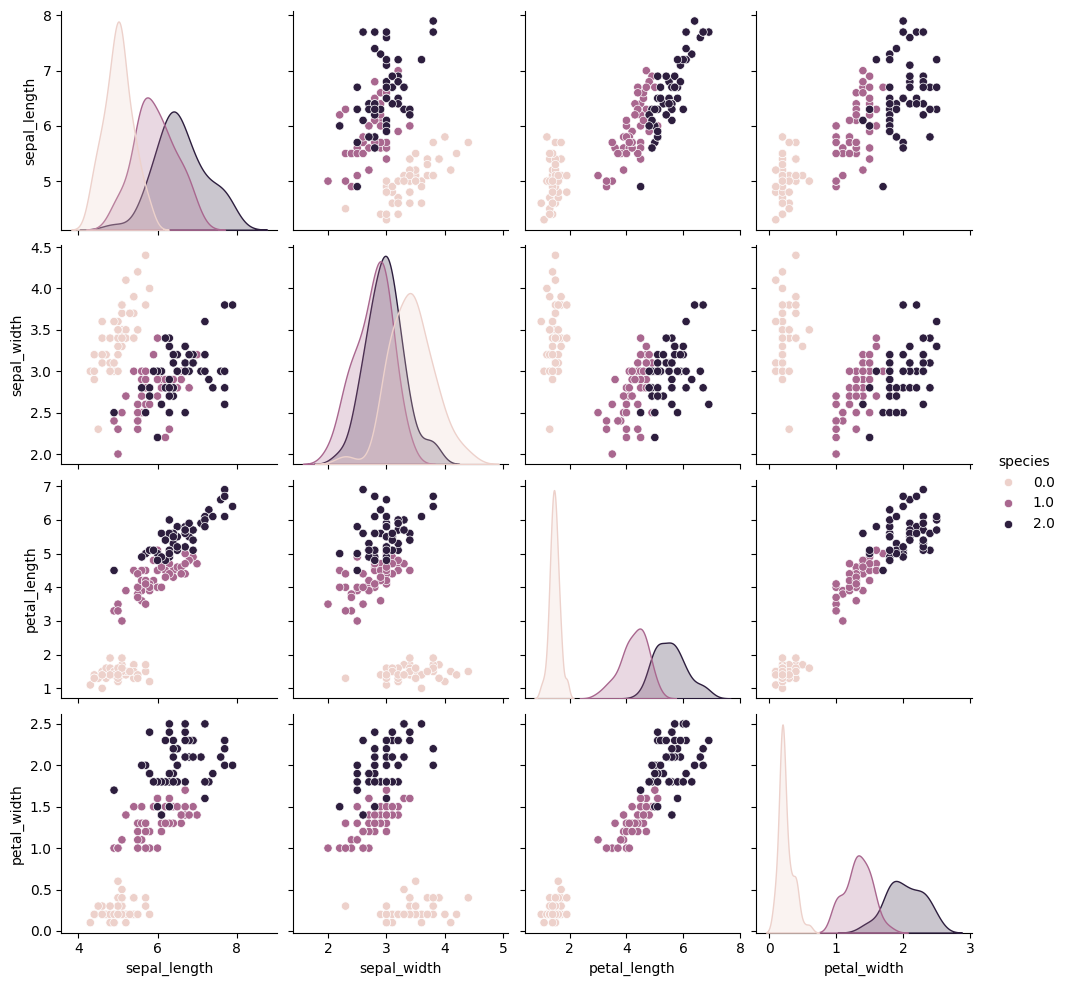

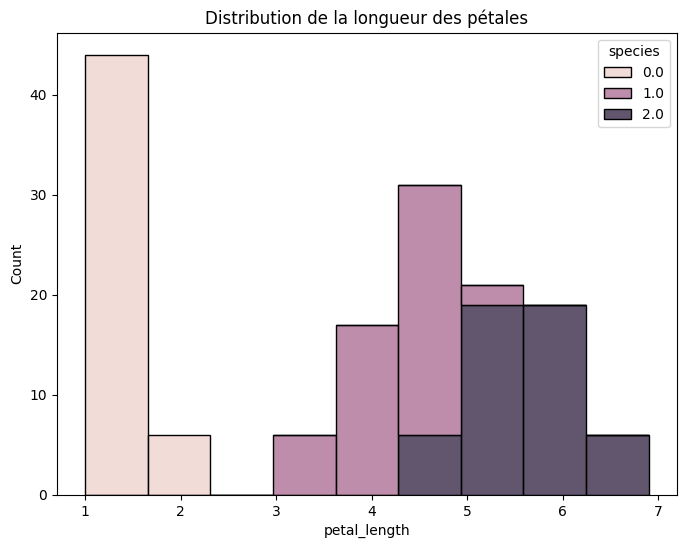

In [3]:
# Étape 2 : Traitement et visualisation des données
# Renommage des colonnes pour plus de clarté
df.columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

# Visualisation des paires de variables
sns.pairplot(df, hue='species')
plt.show()

# Visualisation de la distribution d'une variable (par exemple, la longueur des pétales)
plt.figure(figsize=(8, 6))
sns.histplot(data=df, x='petal_length', hue='species', multiple='stack')
plt.title('Distribution de la longueur des pétales')
plt.show()


# Séparation des données en features (X) et target (y)
X = df.drop('species', axis=1)
y = df['species']

# Division des données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [4]:
# Étape 3 : Construction et entraînement du modèle
# Utilisation d'un arbre de décision (Decision Tree Classifier)
model = DecisionTreeClassifier(random_state=42)

# Entraînement du modèle
model.fit(X_train, y_train)


DecisionTreeClassifier(random_state=42)

Accuracy du modèle : 1.00

Rapport de classification :
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        19
         1.0       1.00      1.00      1.00        13
         2.0       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



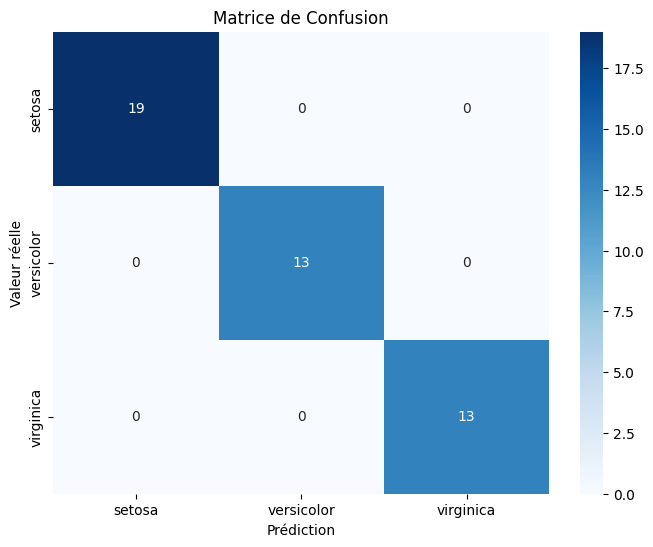

In [5]:
# Étape 4 : Évaluation et visualisation des résultats
# Prédictions sur les données de test
predictions = model.predict(X_test)

# Calcul de l'accuracy
accuracy = accuracy_score(y_test, predictions)
print(f'Accuracy du modèle : {accuracy:.2f}')

# Rapport de classification
print('\nRapport de classification :')
print(classification_report(y_test, predictions))

# Matrice de confusion
cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Prédiction')
plt.ylabel('Valeur réelle')
plt.title('Matrice de Confusion')
plt.show()